# Optimal Posting Strategies on Reddit

By Garrett Hill

## Introduction

Reddit is one of the most popular social media sites on the web today, with an estimated 52 million daily active users. Reddit is different from many other popular social media sites in that is designed around subreddits ("subs"), which are basically forums for a given topic. Users can subscribe to these subs to add them to their home feed, and in addition to leaving comments on posts, users can "upvote" or "downvote" to like or dislike a post. Every user has a "Karma" score, which is an aggregate value roughly equivalent to the total number of upvotes that user has received on their account.

These upvotes and downvotes are mostly worthless, however many Reddit denizens take pride in having high Karma, and many subreddits have established minimum Karma values before you are allowed to make a post on them. This helps prevent brand new accounts (i.e. bots) from spamming the feed. Additionally, posts with higher karma will be shown first when you sort a subreddit by "Top", and posts that receive a large number of upvotes in a short period of time will be displayed first when sorted by "Hot".

As someone who uses Reddit frequently, I found myself wondering if there was an "optimal" posting strategy that would allow me to maximize my user Karma. In the past, I have noticed anecdotally that posts on the front page of Reddit (also called /r/all) seemed to be posted at similar times to each other. This time was usually early to midmorning Eastern Standard Time. However, I had no statistically rigorous evidence for this.

As I thought further about this phenomenon, I wondered what measurable variables might best predict post score? I knew that Reddit has a publicly available API and that this API can be used to see the stored variables for a given post, such as score (upvotes - downvotes). With this in mind, I set about designing this tutorial to guide readers towards the optimal Reddit posting strategy.

This tutorial has five main phases:

1. Data Collection
2. Data Management
3. Exploratory Data Analysis
4. Hypothesis Testing
5. Conclusions

## Data Collection

In order to reproduce the data used in this tutorial, you need to go through Reddit's formal API channels. This means setting up a personal use script (do so [here](https://www.reddit.com/prefs/apps)). Make note of the client ID and secret token, as these will be used for API authentication purposes.

Once the new application is available, set the variables at the beginning of [14] to the appropriate values. These variables are uname (account username), password (account password), client (client ID), secret (client secret), uagent (a unique UserAgent to identify yourself to Reddit), and list_of_subs (the list of subreddits to study).

We are now ready to request data from Reddit. The code first requests an authentication token so that you have permission to access the API, using the previously defined variables to identify ourselves. Then, we take the json object Reddit sends back and get the authentication token out of it. Finally, we use the authentication token to request the top 25 posts from the last month for each of the 50 most subscribed subs (according to [frontpagemetrics.com](https://frontpagemetrics.com/top)). If you decide you want to examine a different set of subreddits, simply change the listings in list_of_subs.

The data needs some clean up to make it easier to analyze later, which is done in clean(). For a given json response from Reddit, we get the number of listings and the list of posts, which are returned as a tuple. This ensures that we can verify that each subreddit produced at least 25 top results, as well as access the data fields for any individual post.

As a note, all time values are to be considered in Coordinated Universal Time (UTC).

In [1]:
# USER VARIABLES
uname    = "your-account-username"
password = "your-account-password"
client   = "your-client-id"
secret   = "your-client-secret"
uagent   = "cmsc320OptimalRedditTutorial/0.1 by " + uname

list_of_subs = ['funny','AskReddit','gaming','aww','Music','pics','worldnews'
               'movies','todayilearned','science','videos','news','Showerthoughts','Jokes',
               'food','askscience','EarthPorn','IAmA','gifs','nottheonion','DIY','books',
               'Art','explainlikeimfive','LifeProTips','space','sports','mildlyinteresting',
               'Documentaries','gadgets','memes','blog','photoshopbattles','tifu','UpliftingNews',
               'GetMotivated','dataisbeautiful','listentothis','history','philosophy','television',
               'InternetIsBeautiful','Futurology','OldSchoolCool','WritingPrompts','personalfinance',
               'nosleep','creepy','TwoXChromosomes','wallstreetbets']
print("Number of subreddits examined: " + str(len(list_of_subs) + 1))

Number of subreddits examined: 50


In [2]:
import requests
import requests.auth

# gets the access token necessary to access the full reddit api
# almost all of this function's code is pulled verbatim from
# https://github.com/reddit-archive/reddit/wiki/OAuth2-Quick-Start-Example
def get_access_tok(uname, password, client, secret):
    # Tell reddit who is requesting permissions, and what type of perms to give
    client_auth = requests.auth.HTTPBasicAuth(client, secret)
    post_data = {
        "grant_type": "password",
        "username": uname,
        "password": password
    }
    headers = {
        "User-Agent": uagent
    }
    
    # get the response from reddit 
    # TODO: ERROR HANDLING
    response = requests.post("https://www.reddit.com/api/v1/access_token",
                         auth=client_auth, data=post_data, headers=headers)
    return response.json()

# For some authentication token and an api endpoint, send a get request to reddit
def get_endpoint_result(auth_tok, endpoint):
    # format the header according to proper parameters
    headers = {
        "Authorization": "bearer " + auth_tok,
        "User-Agent": uagent
    }
    
    # get the response from reddit
    # TODO: Error handling
    response = requests.get("https://oauth.reddit.com" + endpoint, headers=headers)
    return response.json()
   
# For some authentication token, api endpoint, and subreddit, send a get request to reddit
def get_end_for_sub(auth_tok, endpoint, sub):
    endp = get_endpoint_result(auth_tok, "/r/" + sub + endpoint)
    return endp

# Tidy our data so we can put it in a dataframe later
def clean(endp):
    num_posts = endp['data']['dist']
    posts     = endp['data']['children']
    return (num_posts, posts)
    
# get the access token back from reddit
json = get_access_tok(uname, password, client, secret)
auth_tok = json['access_token']

# For every subreddit, get the top 25 most popular posts of the month and store the results
sub_data = {}
for sub in list_of_subs:
    endp = get_end_for_sub(auth_tok, "/top?t=year", sub)
    cleaned = clean(endp)
    sub_data[sub] = cleaned
    
print("Number of subs: " + str(len(sub_data)+1))
# sub_data

Number of subs: 50


## Data Management

Now that we have a set of posts to work with, we can store them and their associated variables in a pandas dataframe. Each observation represents one post. While there are many variables associated with each observation in our original dataset, the ones we care about are subreddit (subreddit name), ups (number of upvotes), and created_utc (timestamp at time of posting). In addition to populating these fields, we process the created_utc into a more human readible datetime object, which we then save in an additional column. Finally, we have one more column to store just the hour of the datetime.

In [3]:
import pandas as pd
from datetime import datetime

# convert the universal time coordinated to a datetime object

# Empty data dictionary to store individual post data in
# Each field entry is a mapping of unique integer post ids
# to the relevant named variable in sub_data
data = {
    "subreddit": {},
    "score": {},
    "hour": {},
    "created_utc": {},
    "datetime": {}
}

# For every post in our data, populate the data dictionary
i = 0
for sub in sub_data:
    posts = sub_data[sub][1]
    for post in posts:
        # This data is already in correct form, no processing needed
        data['subreddit'][i] = sub
        data['score'][i] = int(post['data']['ups'])
        
        # Wrangle timestamps into human readable format
        timestamp = int(post['data']['created_utc'])
        dt = datetime.fromtimestamp(timestamp)
        data['created_utc'][i] = timestamp
        data['datetime'][i] = dt
        data['hour'][i] = dt.hour
        i = i + 1

# Put all of our data into a dataframe
df = pd.DataFrame(data)
df

,subreddit,score,hour,created_utc,datetime
0,funny,208213,13,1633368319,2021-10-04 13:25:19
1,funny,191401,9,1631280442,2021-09-10 09:27:22
2,funny,179018,6,1645441947,2022-02-21 06:12:27
3,funny,171829,19,1640910606,2021-12-30 19:30:06
4,funny,171373,17,1644965832,2022-02-15 17:57:12
...,...,...,...,...,...
1188,wallstreetbets,72893,12,1652544006,2022-05-14 12:00:06
1189,wallstreetbets,66254,9,1641824621,2022-01-10 09:23:41
1190,wallstreetbets,66069,11,1648394135,2022-03-27 11:15:35
1191,wallstreetbets,65372,11,1646064326,2022-02-28 11:05:26


## Exploratory Data Analysis

Now that we have a list of posts with both score and time, we can start poking around to see what posts perform the best. The first question to ask is what are the mean and median posting times? 

If we want to further constrain our data, we can look at just the posts that are more successfull than 50% of all other posts (i.e. their score is above the median score). Now we look again at the mean and median post times and see how they change compared to the unconstrained data.

In [4]:
# sort by score with highest score shown first
df.sort_values(by=['score'],ascending=False)
h_median = df['hour'].median()
h_mean   = df['hour'].mean()
print("total hour median: " + str(h_median))
print("total hour mean: " + str(h_mean))

# constrain to only those who scored better than the median, and check the median hour
s_median = df['score'].median()
constr_df = df[df['score'] > s_median]
constr_h_median = constr_df['hour'].median()
constr_h_mean = constr_df['hour'].mean()

print("constr hour median: " + str(constr_h_median))
print("constr hour mean: " + str(constr_h_mean))

# Compare the values of the constrained data to the unconstrained data
diff_med = h_median - constr_h_median
diff_mean = h_mean - constr_h_mean

print("diff_med: " + str(diff_med))
print("diff_mean: " + str(diff_mean))

total hour median: 12.0
total hour mean: 12.166806370494552
constr hour median: 12.0
constr hour mean: 12.560402684563758
diff_med: 0.0
diff_mean: -0.3935963140692067


According to the difference in means, the unconstrained dataset tends to have a higher hour value than the constrained set. That is, the more successfull posts tended to be posted earlier in the day.

Now I would like to examine if each individual subreddit follows this general trend. The scatterplots below shows the relation between posting hour on the x axis and score on the y.

/tmp/ipykernel_21404/566577350.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig,ax = plt.subplots()


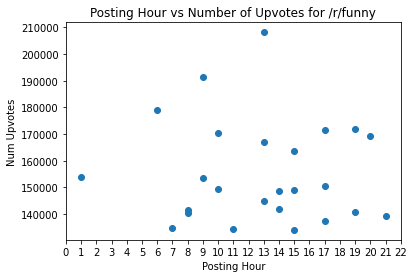

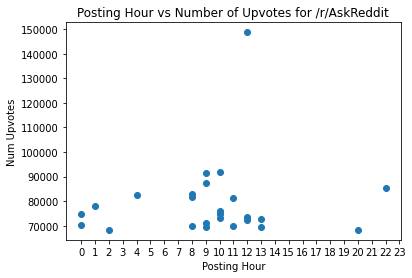

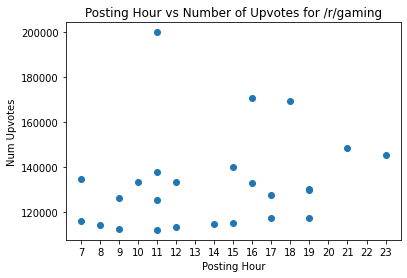

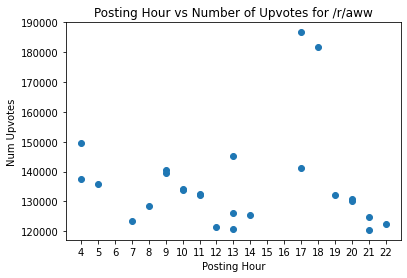

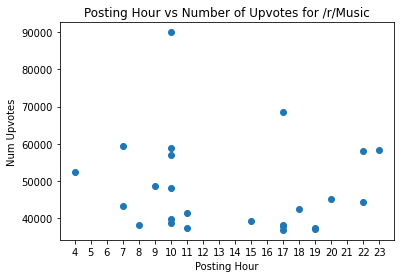

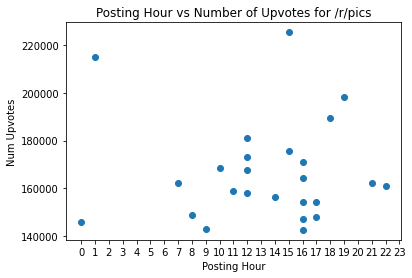

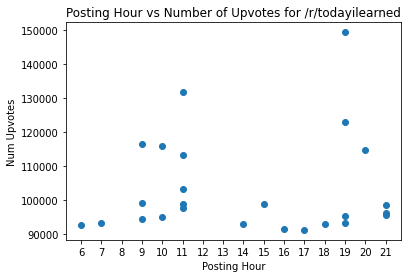

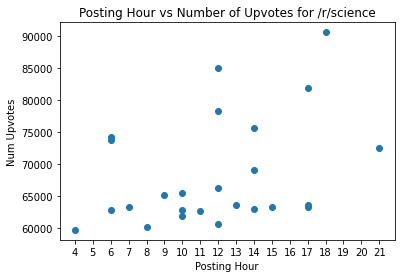

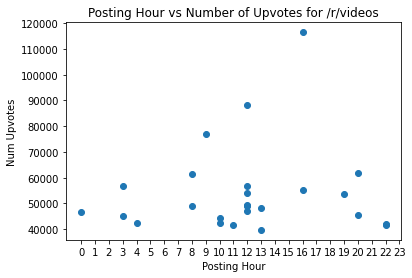

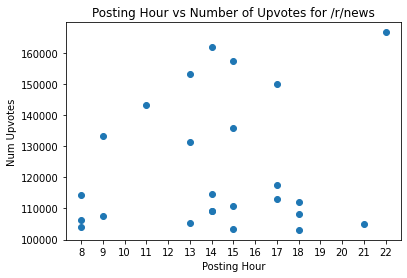

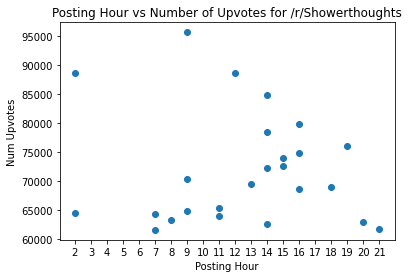

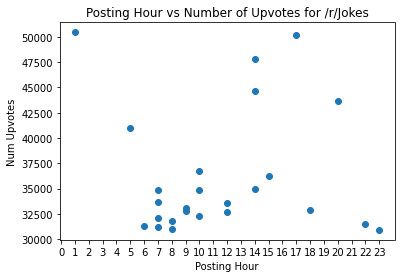

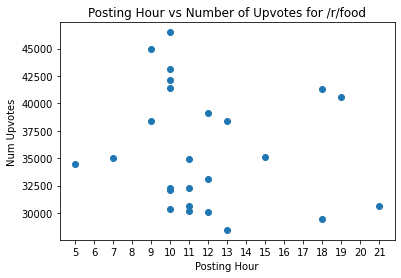

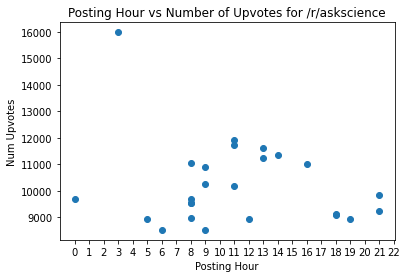

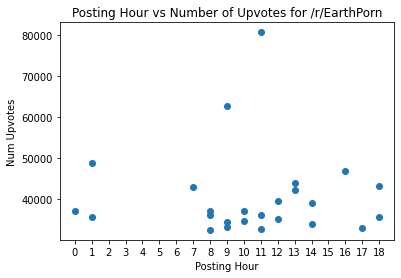

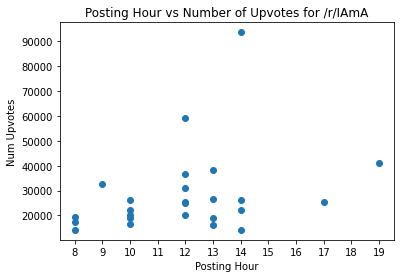

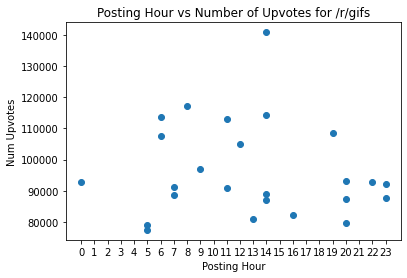

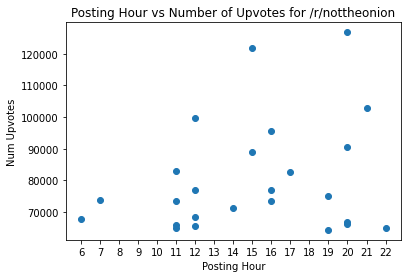

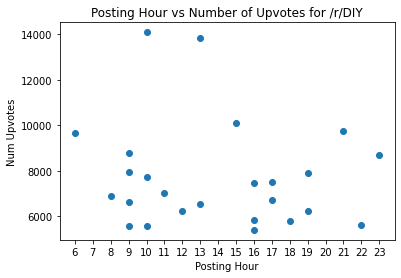

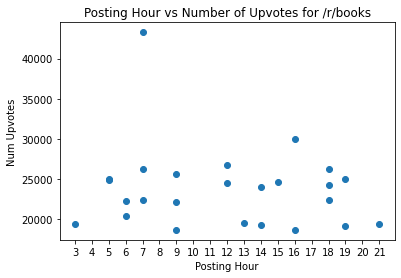

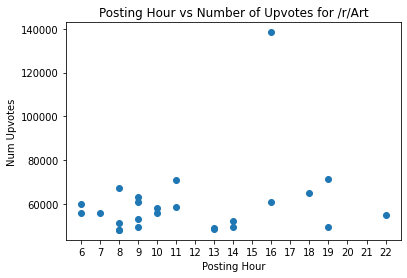

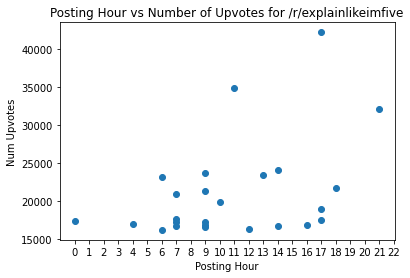

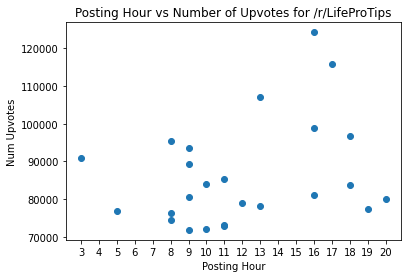

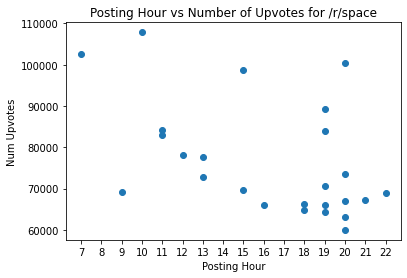

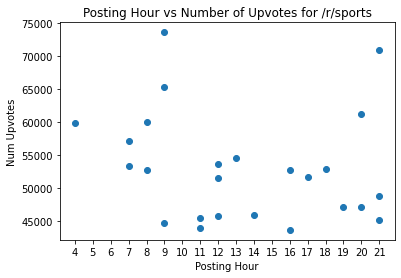

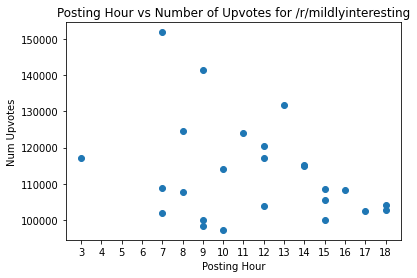

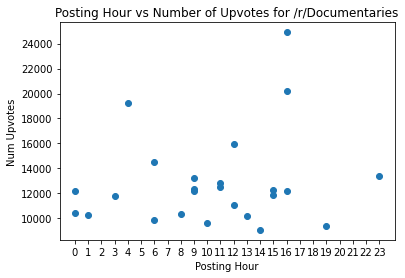

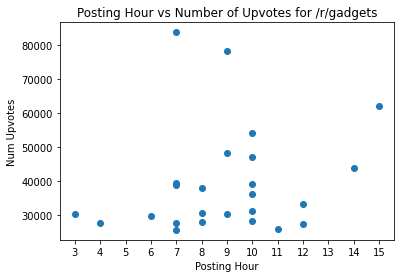

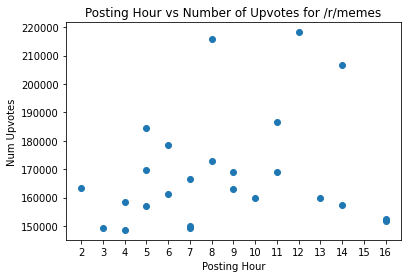

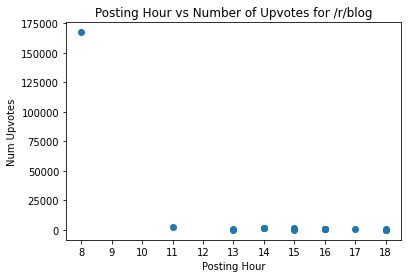

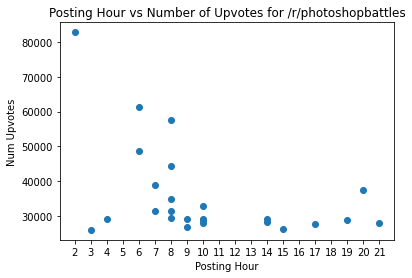

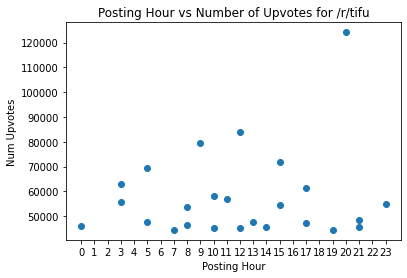

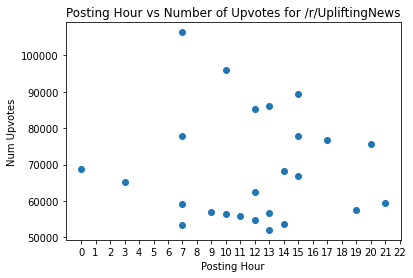

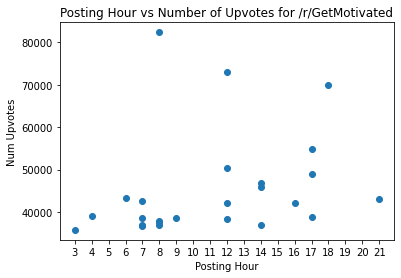

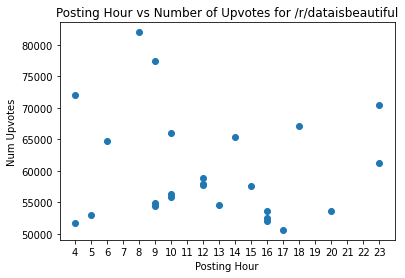

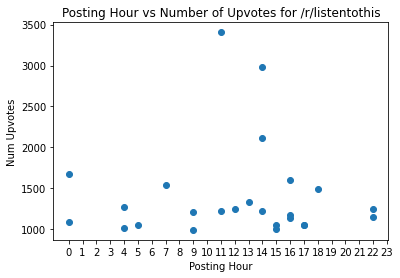

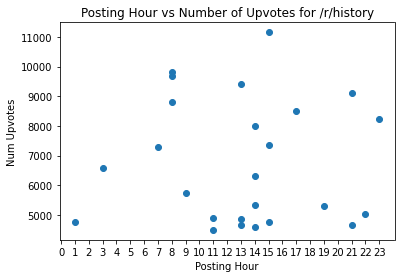

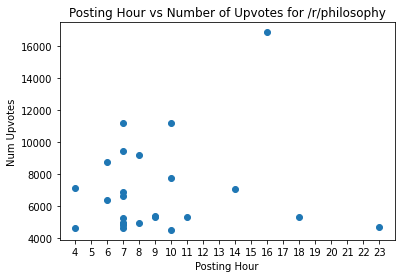

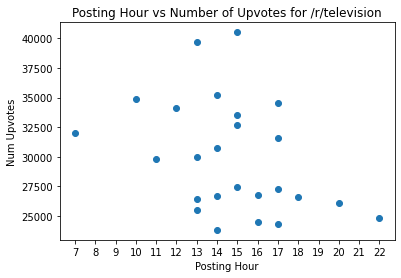

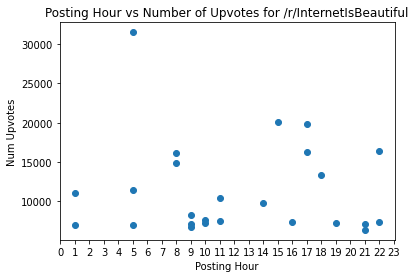

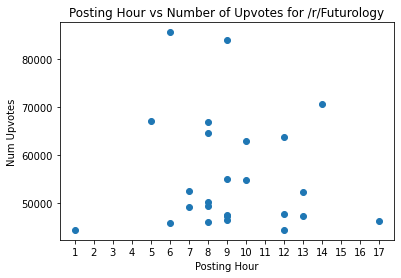

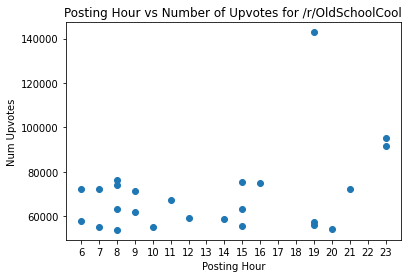

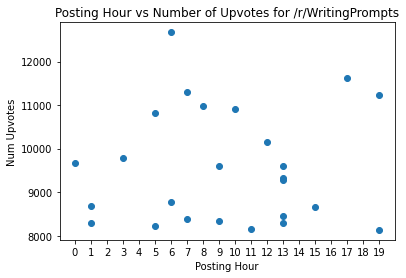

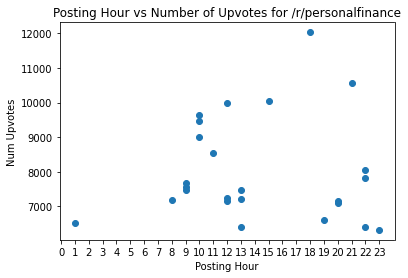

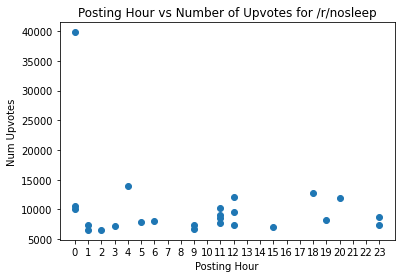

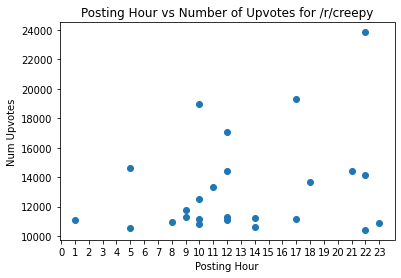

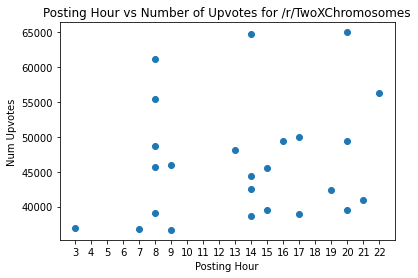

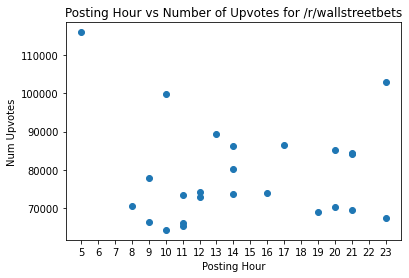

In [5]:
from matplotlib import pyplot as plt
import numpy as np

# Graph time vs score for a given sub
def time_vs_score_by_sub(sub):   
    
    sdf = df[df['subreddit'] == sub]
    x = sdf['hour']
    y = sdf['score']
    
    # initialize the graph
    fig,ax = plt.subplots()
    ax.set_xticks(range(0,24))
    ax.set_xlabel("Posting Hour")
    ax.set_ylabel("Num Upvotes")
    ax.set_title("Posting Hour vs Number of Upvotes for /r/" + str(sub))
    
    # show the graph
    ax.scatter(x,y)
    
for sub in df['subreddit'].unique():
    time_vs_score_by_sub(sub)

Just from looking at these graphs, it appears to me that there is at least a weak correlation between posting hour and upvotes, with how weak that correlation is being dependant on subreddit.

## Hypothesis Testing

Based on my preliminary investigation, I hypothesize that we can predict the score of a given post if we know its subreddit and post time. However, I think that how successful our predictions are will depend on the subreddit. To test this prediction, I propose using a linear estimate model with interaction terms on subreddit. First, I will change my dataframe to have a column for every unique subreddit, with either 0 or 1 indicating if a post is from that subreddit.

In [6]:
for (i, row) in df.iterrows():
    df.at[i, row['subreddit']] = 1
df = df.replace(np.nan, 0)
df

,subreddit,score,hour,created_utc,datetime,funny,AskReddit,gaming,aww,Music,...,television,InternetIsBeautiful,Futurology,OldSchoolCool,WritingPrompts,personalfinance,nosleep,creepy,TwoXChromosomes,wallstreetbets
0,funny,208213,13,1633368319,2021-10-04 13:25:19,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,funny,191401,9,1631280442,2021-09-10 09:27:22,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,funny,179018,6,1645441947,2022-02-21 06:12:27,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,funny,171829,19,1640910606,2021-12-30 19:30:06,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,funny,171373,17,1644965832,2022-02-15 17:57:12,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,wallstreetbets,72893,12,1652544006,2022-05-14 12:00:06,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1189,wallstreetbets,66254,9,1641824621,2022-01-10 09:23:41,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1190,wallstreetbets,66069,11,1648394135,2022-03-27 11:15:35,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1191,wallstreetbets,65372,11,1646064326,2022-02-28 11:05:26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Now, just to experiment, let's see how we do with just a simple linear regression on hour vs score.

In [7]:
from sklearn.linear_model import LinearRegression

x = df[['hour']]
y = df['score']
reg = LinearRegression().fit(x,y)
m = reg.coef_[0]
b = reg.intercept_

scores = []
for (i,row) in df.iterrows():
    x = row['hour']
    predicted = m*x + b
    actual = row['score']
    scores.append(predicted - actual)

scores = np.array(scores)
print('mean error: ' + str(scores.mean()))
print('max error: ' + str(scores.max()))
print('min error: ' + str(scores.min()))

mean error: -1.5613119440326547e-12
max error: 61745.087324825225
min error: -166256.79642333055


While the mean error is extremely close to zero, there are clearly subreddits where this model simply does not reflect the reality of when users are upvoting posts, as demonstrated by the extreme maximum and minimum errors. With that in mind, let's try using a polynomial regression based on both the hour and subreddit for a given post.

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

subs = df['subreddit'].unique()
degree = 1 + (1+len(subs))
cols = ['hour']
for col in df.columns.tolist()[5:53]:
    cols.append(col)
x = df[cols]
y = df['score']

poly = PolynomialFeatures(interaction_only=True,include_bias = False)
poly.fit_transform(x)
reg = LinearRegression().fit(x,y)

print("m: " + str(reg.coef_[0]))
print("b: " + str(reg.intercept_))
print("offsets: " + str(reg.coef_[1:]))


m: 51.324943589518334
b: 56772.059946526904
offsets: [ 98035.48777778  22145.47157922  75240.90983645  78431.27679358
  -9630.03817258 109369.2248026   45968.77885225  10937.30571912
  -3198.90627186  65575.55285676  14528.92475748 -21119.60430345
 -21575.20027637 -47115.24631699 -16759.19935986 -29068.42627186
  38926.87377327  22793.58589963 -49743.54316129 -33635.25327411
   2354.2917146  -36238.55633955  28936.45372814  19016.34296958
  -4318.89419063  55488.50370558 -44426.17336437 -17784.39844335
 111557.10453183 -47430.98965593 -21466.54837565    321.30672589
  11388.21272137 -11845.67331924   2670.05775522 -55976.65226734
 -50673.61620417 -50333.63642981 -27552.76311616 -45996.41126058
  -1534.24942755  11974.39679358 -47680.39441627 -49473.26114775
 -47149.1134095  -44220.57721093 -10995.1461816   21282.40887481]


Great, lots numbers on a screen. What do they mean? If we think about our regression as a line, that means it has a slope "m" and an intercept "b", giving the common formula of

``` y = mx + b ```

In the numbers shown above, the "m" is approximately 51.3, and the "b" is 56,771. This means that for any given post, we can expect a baseline of 56,771 upvotes, plus 51.3 upvotes per each additional hour above 0. The rest of the numbers are offset values for individual subreddits. For example, the last subreddit in the list, wallstreetbets, has an additional offset of approximately positive 21281. This means wallstreetbet's baseline is 21281 upvotes than the model's as a whole. If the number were negative, then their baseline would be 21281 upvotes lower than the model's as a whole. We add this new offset "c" to our baseline to get

``` y = mx + b + c ```

Now that we know what these numbers mean, let's show the regression on the graphs from before. The regression line is in orange, and the r^2 value tells us how "wrong" our model is for a given subreddit (with 0 to 1 meaning wrong to correct, respectively).

/tmp/ipykernel_21404/1005345858.py:31: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig,ax = plt.subplots()


{'funny': 0.0024284313944125373, 'AskReddit': 0.014506244825191769, 'gaming': 0.05051900859444746, 'aww': 1.651858951960963e-05, 'Music': 0.01509928333481169, 'pics': 0.0002845111583890218, 'todayilearned': 0.004664519952925297, 'science': 0.12949234566418746, 'videos': 0.006583160892264333, 'news': 0.023922484743751308, 'Showerthoughts': 0.0067643863931481085, 'Jokes': 0.0003116170977169963, 'food': 0.019028995735595678, 'askscience': 0.04446176814838984, 'EarthPorn': 0.00017293645642663748, 'IAmA': 0.10136800919529125, 'gifs': 0.008353515959545168, 'nottheonion': 0.05559614763234884, 'DIY': 0.018281014021554246, 'books': 0.021431678333899567, 'Art': 0.05121665937744599, 'explainlikeimfive': 0.17773659160550767, 'LifeProTips': 0.08805232566131407, 'space': 0.23930474730645943, 'sports': 0.03633577477516538, 'mildlyinteresting': 0.097781445156375, 'Documentaries': 0.03173342158749675, 'gadgets': 0.0385627968173683, 'memes': 0.03286528644499203, 'blog': 0.4447962077218582, 'photoshopbat

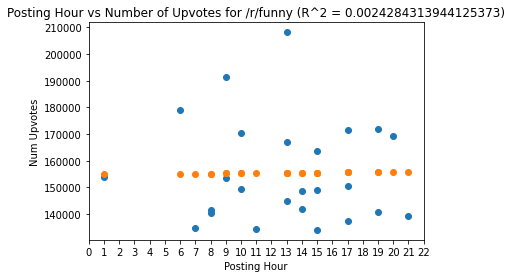

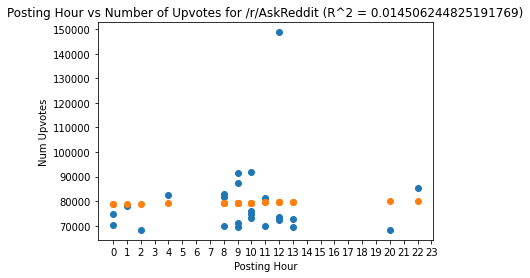

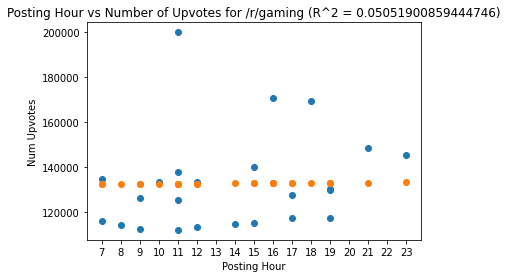

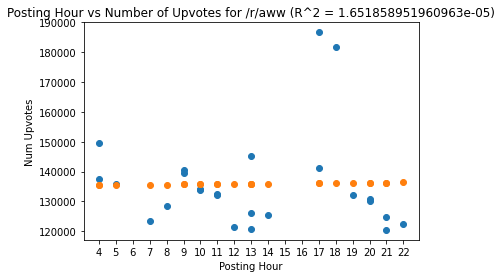

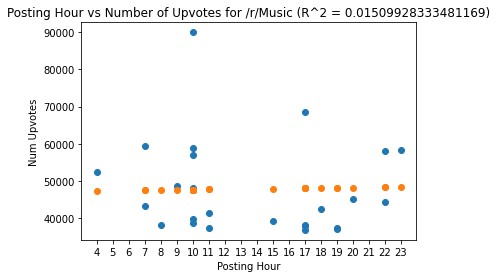

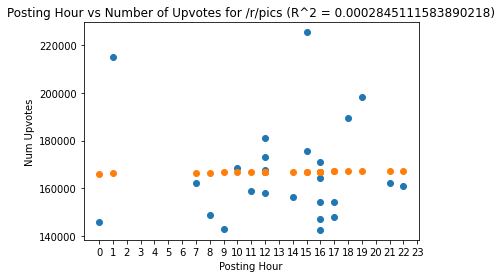

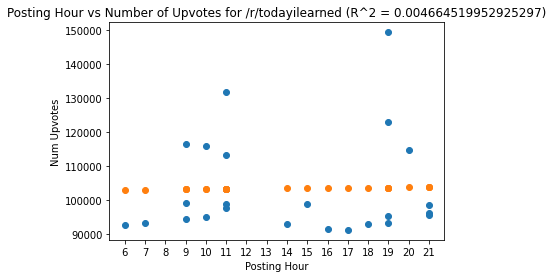

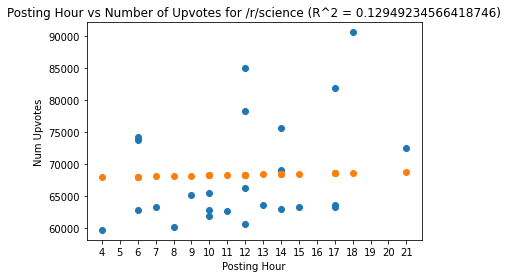

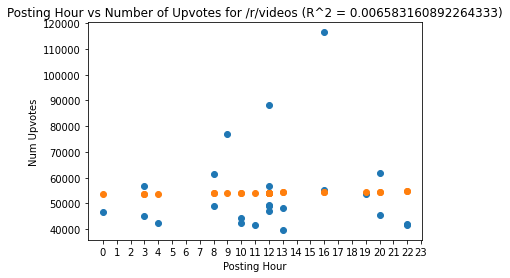

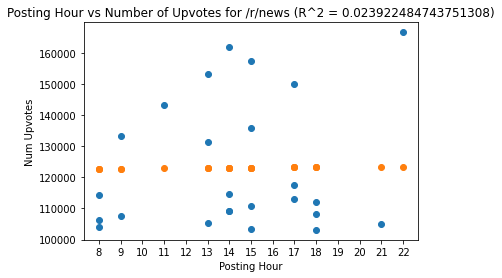

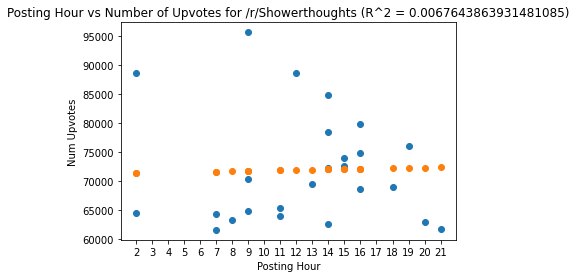

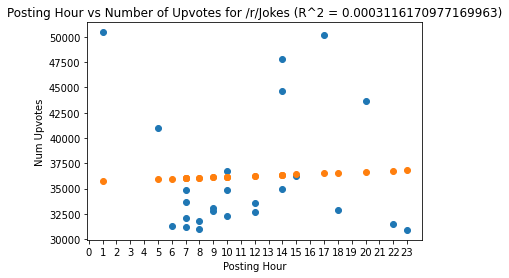

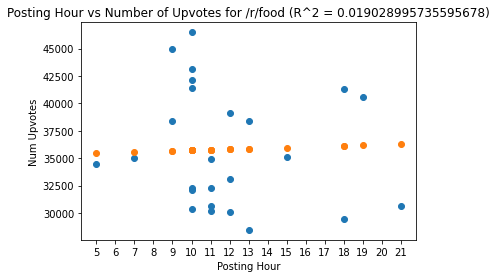

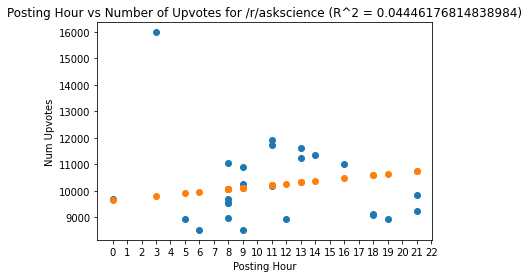

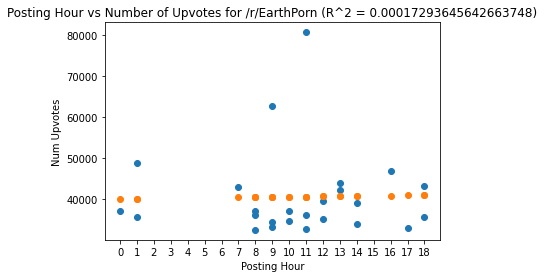

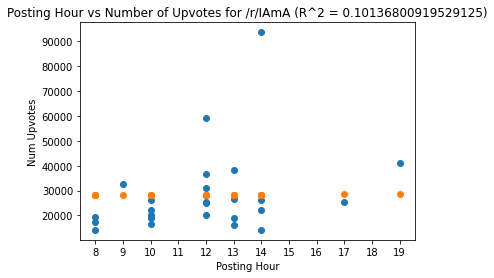

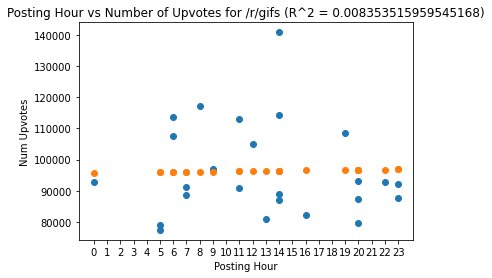

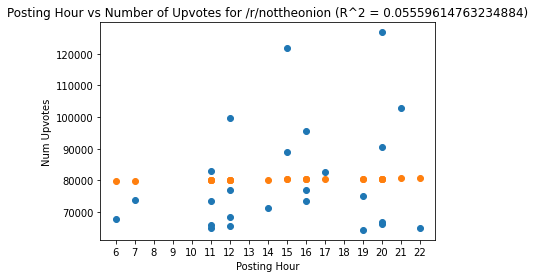

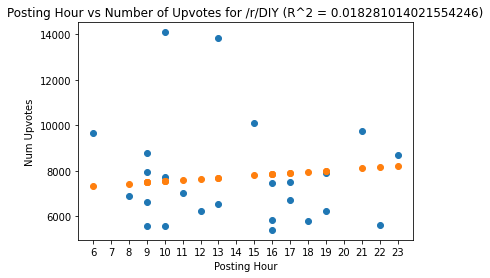

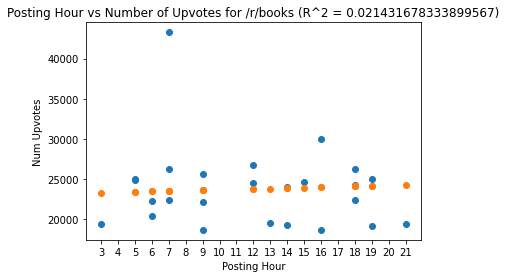

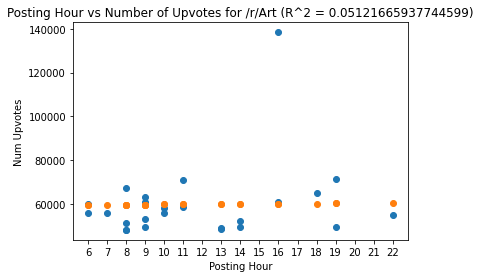

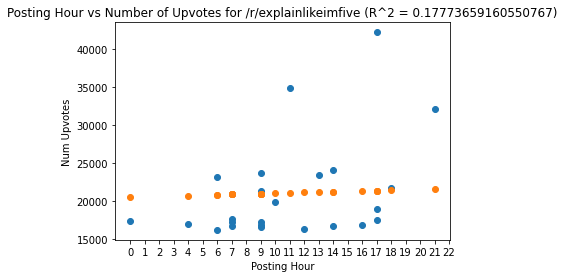

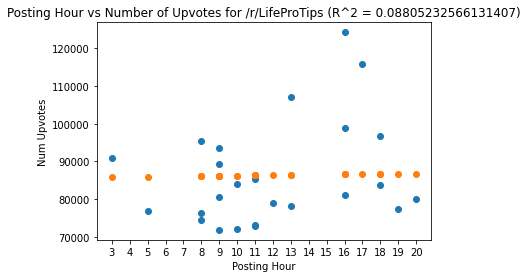

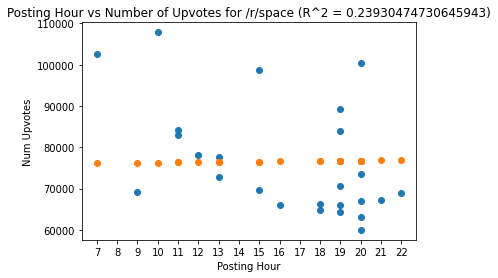

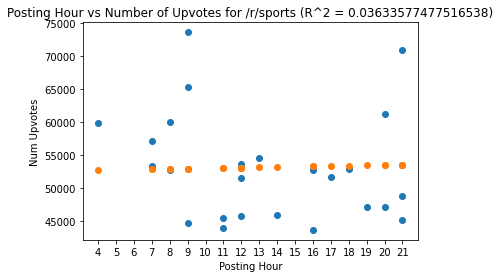

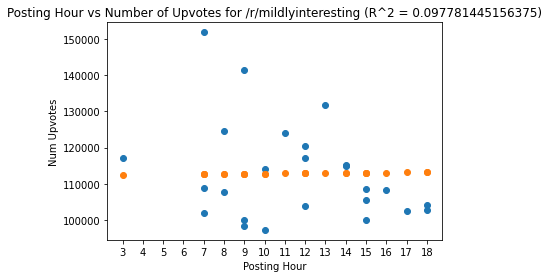

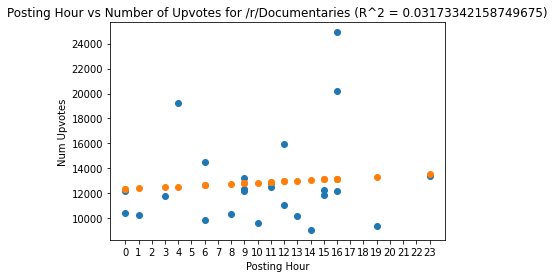

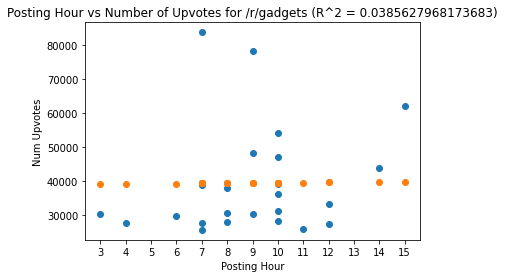

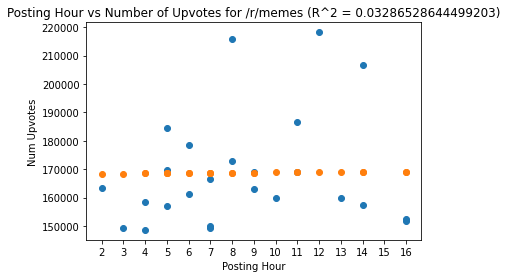

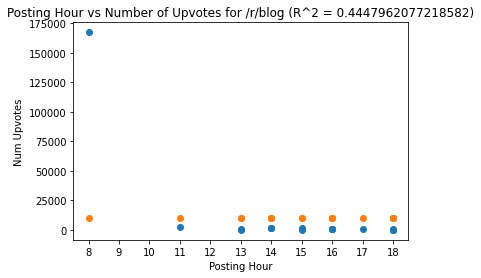

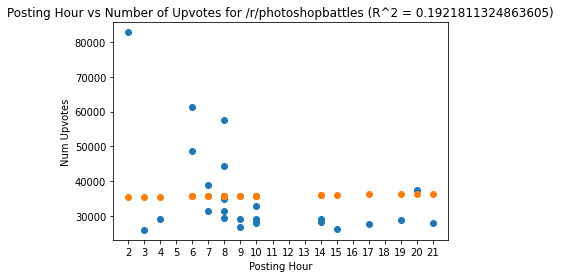

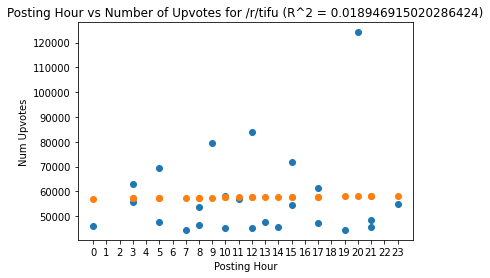

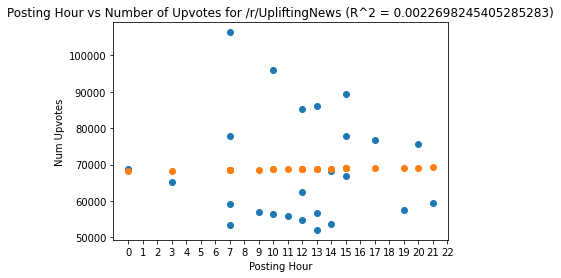

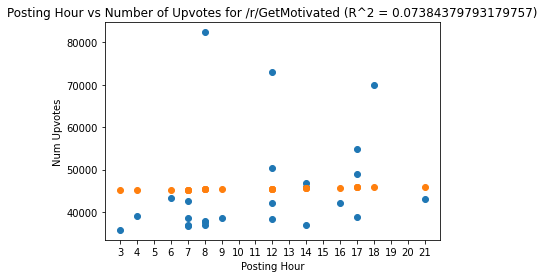

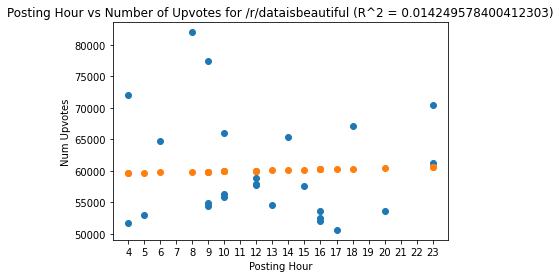

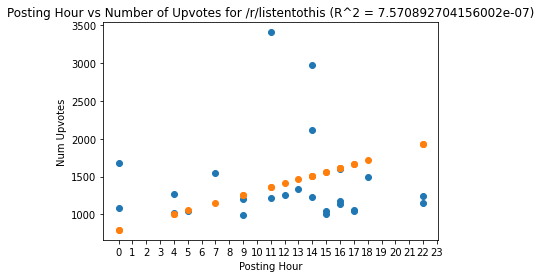

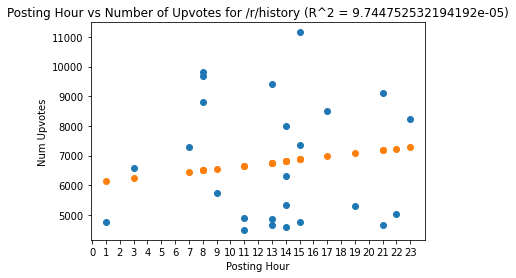

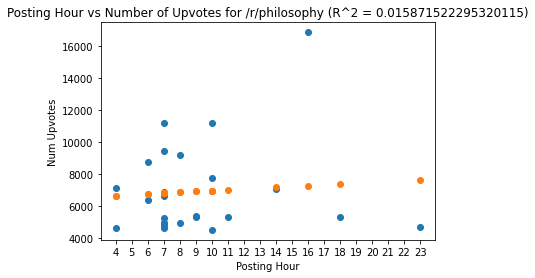

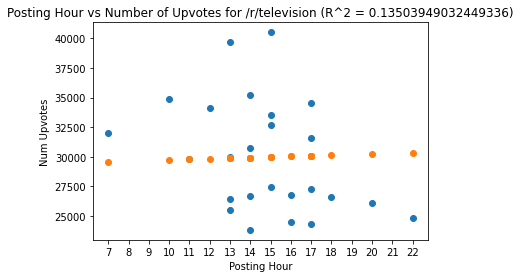

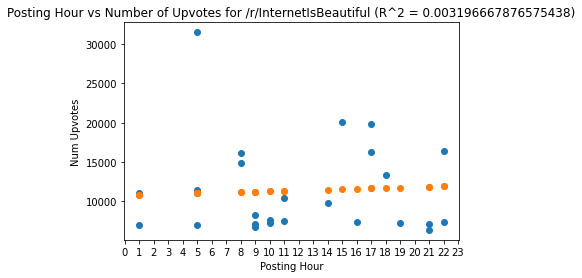

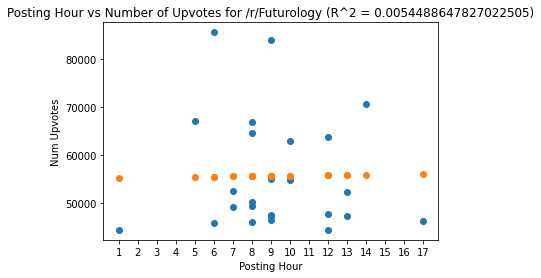

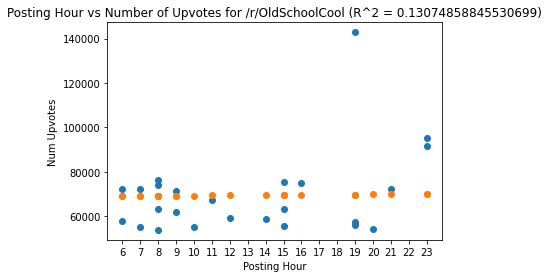

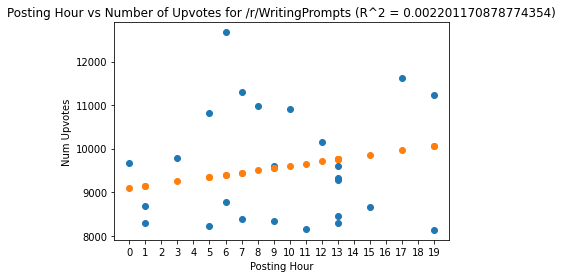

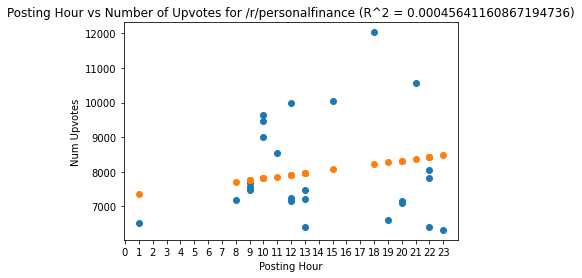

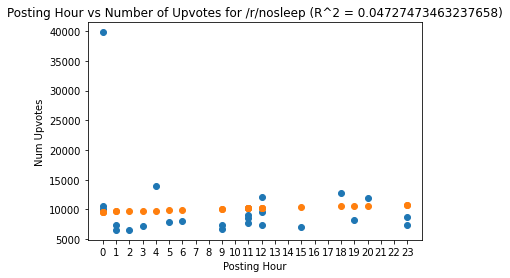

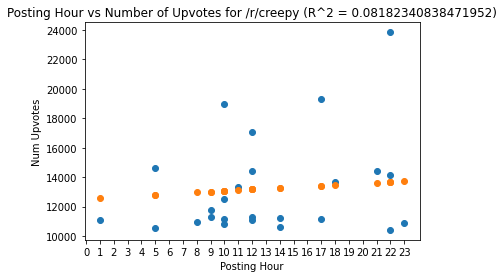

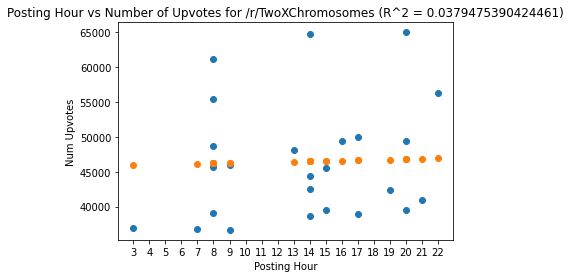

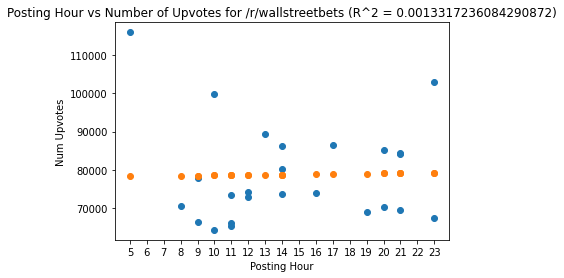

In [9]:
from matplotlib import pyplot as plt
import numpy as np

coefs = reg.coef_
inter = reg.intercept_
r2s = {}

# Associate all of the coefficients with their proper subreddit
cs = {}
i = 1
for col in df.columns.tolist()[5:53]:
    cs[col] = coefs[i]
    i = i + 1

# Graph time vs score for a given sub with regression
def tvs_r(sub):   
    sdf = df[df['subreddit'] == sub]
    x = sdf['hour']
    y = sdf['score']
    
    # Get the appropriate constants to calculate predicted y
    m = coefs[0]
    b = inter
    c = cs[sub]
    p_y = [m*x + b + c for x in x]
    r = np.corrcoef(y,p_y)[0,1]
    r2 = r**2
    r2s[sub] = r2
    
    # initialize the graph
    fig,ax = plt.subplots()
    ax.set_xticks(range(0,24))
    ax.set_xlabel("Posting Hour")
    ax.set_ylabel("Num Upvotes")
    title = "Posting Hour vs Number of Upvotes for /r/" + str(sub) + " (R^2 = " + str(r2) + ")"
    ax.set_title(title)
    
    # show the graph
    ax.scatter(x,y)
    ax.scatter(x,p_y)


# Make the graph for every unique sub
for sub in df['subreddit'].unique():
    tvs_r(sub)
    
print(r2s)

## Conclusions

Unfortunately, it appears that my prediction was wrong. There are no subreddits with an r^2 value higher than even 0.5, meaning that this model tends to produce very erroneous predictions. So what does this tell us? 

The first thing it tells me is that among the top posts on reddit, it doesn't seem to make any tangible difference what time you post at. This could be for a few reason. One reason is that despite Reddit being associated with American culture, the platform has many users in alternate timezones. These non-US accounts engaging with new content at all hours of the day, meaning that some posts will eventually be upvoted to the physical top of the sub for that day, further boosting engagement.

The second thing it tells me is that even among the top posts on a subreddit, the amount of upvotes received varies wildly. For example, /r/AskReddit ranges from approximately 70,000 upvotes to 150,000 for a difference of 80,000. The difference between the most and least successful posts here is larger than the maximum upvotes received in many other subreddits, such as /r/creepy.

Moving forward, in addition to testing how more variables per post interact, I would be very interested in comparing the distributions of top scores within individual subreddits over time. I think that this would give more context to some of the information shown on these graphs.

## Resources

Below are some additional resources that I found useful or interesting while researching and developing this project.

- [Reddit API](https://github.com/reddit-archive/reddit/wiki/API)
- [This website's source code](https://github.com/gahill18/gahill18.github.io)